<a href="https://colab.research.google.com/github/sneharoy0906-rgb/PW_Assingments/blob/main/EDA_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd

In [39]:
df = pd.read_csv(r"/content/House Price India.csv")

In [40]:
# 1. What is the average, median, and standard deviation of house prices

print("Average :", df['Price'].mean())
print("Median  :", df['Price'].median())
print("Std Dev :", df['Price'].std())

Average : 538932.2183310534
Median  : 450000.0
Std Dev : 367532.3808039669


In [41]:
# 2. Which number of bedrooms is most common

# Most common number of bedrooms
most_common = df['number of bedrooms'].mode()[0]
print("Most Common Bedrooms:", most_common)

# See full distribution
print(df['number of bedrooms'].value_counts())

Most Common Bedrooms: 3
number of bedrooms
3     6612
4     4724
2     1844
5     1079
6      176
1      136
7       30
8       11
9        3
10       3
33       1
11       1
Name: count, dtype: int64


In [42]:
# 3. Check if the price data is skewed

skewness = df['Price'].skew()
print("Skewness:", skewness)

Skewness: 4.269297720707116


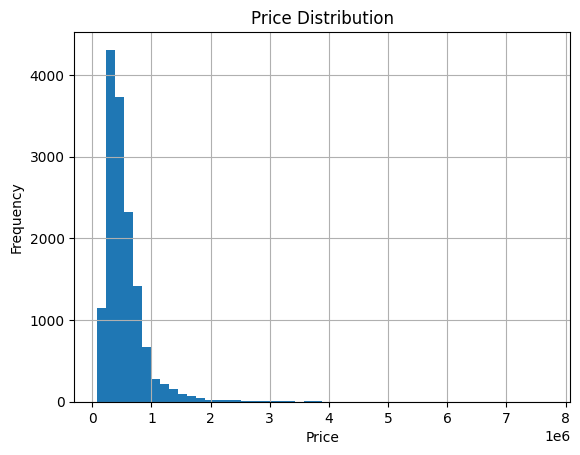

In [43]:
# Bonus – Visual confirmation:

import matplotlib.pyplot as plt

df['Price'].hist(bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [44]:
# 4.What is the average price for each number of bedrooms

avg_price_by_bedroom = df.groupby('number of bedrooms')['Price'].mean()
print(avg_price_by_bedroom)

number of bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
4     6.361988e+05
5     7.752550e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
9     7.766663e+05
10    8.200000e+05
11    5.200000e+05
33    6.400000e+05
Name: Price, dtype: float64


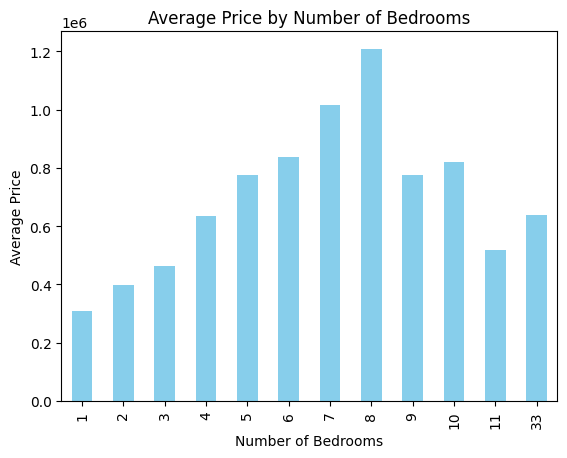

In [45]:
# Bonus – Visual

avg_price_by_bedroom.plot(kind='bar', color='skyblue')
plt.title("Average Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.show()

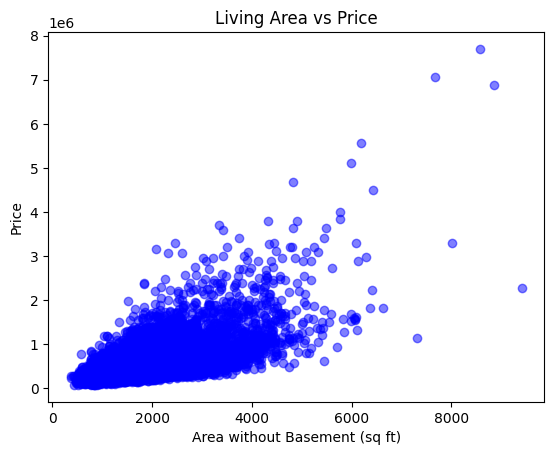

Correlation: 0.6152204198678108


In [46]:
# 5. What is the relationship between living area and price? (Use : Area without Basement)

import seaborn as sns
import matplotlib.pyplot as plt


# Scatter plot - Area without Basement vs Price
plt.scatter(df['Area of the house(excluding basement)'], df['Price'], alpha=0.5, color='blue')
plt.title("Living Area vs Price")
plt.xlabel("Area without Basement (sq ft)")
plt.ylabel("Price")
plt.show()

# Correlation value
corr = df['Area of the house(excluding basement)'].corr(df['Price'])
print("Correlation:", corr)

In [47]:
# 6.Identify any anomalies where houses have high prices but low areas.

# Define thresholds
high_price = df['Price'].quantile(0.75)
low_area = df['Area of the house(excluding basement)'].quantile(0.25)

# Filter anomalies
anomalies = df[(df['Price'] > high_price) &
(df['Area of the house(excluding basement)'] < low_area)]

print("Number of Anomalies:", len(anomalies))
print(anomalies[['Price', 'Area of the house(excluding basement)']].head())

Number of Anomalies: 139
      Price  Area of the house(excluding basement)
101  657100                                   1050
174  675000                                    930
176  650000                                   1160
258  690000                                    980
353  712000                                   1150


In [48]:
# 7.Compare average price based on number of floors and houses with or without waterfront.

# Average price by number of floors
avg_price_floors = df.groupby('number of floors')['Price'].mean()
print("Average Price by Floors:")
print(avg_price_floors)

# Average price by waterfront
avg_price_waterfront = df.groupby('waterfront present')['Price'].mean()
print("\nAverage Price by Waterfront:")
print(avg_price_waterfront)

Average Price by Floors:
number of floors
1.0    4.369769e+05
1.5    5.549301e+05
2.0    6.487372e+05
2.5    1.106233e+06
3.0    5.663281e+05
3.5    1.205875e+06
Name: Price, dtype: float64

Average Price by Waterfront:
waterfront present
0    5.304174e+05
1    1.641902e+06
Name: Price, dtype: float64


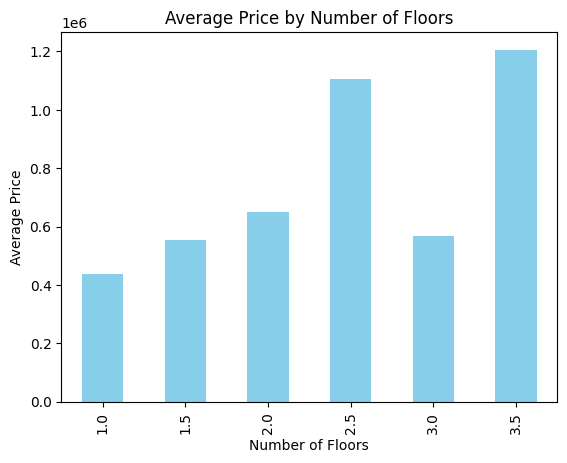

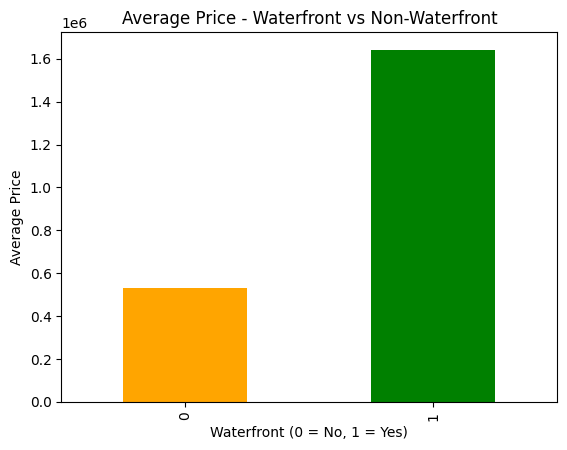

In [49]:
# Bonus – Visual

# Floors chart
avg_price_floors.plot(kind='bar', color='skyblue')
plt.title("Average Price by Number of Floors")
plt.xlabel("Number of Floors")
plt.ylabel("Average Price")
plt.show()

# Waterfront chart
avg_price_waterfront.plot(kind='bar', color=['orange', 'green'])
plt.title("Average Price - Waterfront vs Non-Waterfront")
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Average Price")
plt.show()

In [50]:
# 8. Identify the minimum and maximum house price. What does this indicate

min_price = df['Price'].min()
max_price = df['Price'].max()

print("Minimum Price:", min_price)
print("Maximum Price:", max_price)

# See the actual rows
print("\nCheapest House:")
print(df[df['Price'] == min_price])

print("\nMost Expensive House:")
print(df[df['Price'] == max_price])

Minimum Price: 78000
Maximum Price: 7700000

Cheapest House:
             id   Date  number of bedrooms  number of bathrooms  living area  \
242  6762831616  42495                   2                  1.0          780   

     lot area  number of floors  waterfront present  number of views  \
242     16344               1.0                   0                0   

     condition of the house  ...  Built Year  Renovation Year  Postal Code  \
242                       1  ...        1942                0       122056   

     Lattitude  Longitude  living_area_renov  lot_area_renov  \
242    52.7039    -114.47               1700           10387   

     Number of schools nearby  Distance from the airport  Price  
242                         2                         51  78000  

[1 rows x 23 columns]

Most Expensive House:
               id   Date  number of bedrooms  number of bathrooms  \
10503  6762810020  42655                   6                  8.0   

       living area  lot area  

In [51]:
print(df.columns.tolist())

['id', 'Date', 'number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Price']


In [52]:
for col in df.columns:
    print(col)

id
Date
number of bedrooms
number of bathrooms
living area
lot area
number of floors
waterfront present
number of views
condition of the house
grade of the house
Area of the house(excluding basement)
Area of the basement
Built Year
Renovation Year
Postal Code
Lattitude
Longitude
living_area_renov
lot_area_renov
Number of schools nearby
Distance from the airport
Price


In [53]:
# Automatically find and use location column
location_cols = [col for col in df.columns if 'zip' in col.lower() or
                 'area' in col.lower() or
                 'location' in col.lower() or
                 'code' in col.lower()]
print("Location columns found:", location_cols)

# Use first match automatically
loc_col = location_cols[0]
avg_price_location = df.groupby(loc_col)['Price'].mean()
top_locations = avg_price_location.sort_values(ascending=False).head(10)
print(top_locations)

Location columns found: ['living area', 'lot area', 'Area of the house(excluding basement)', 'Area of the basement', 'Postal Code', 'living_area_renov', 'lot_area_renov']
living area
12050    7700000.0
10040    7060000.0
9890     6890000.0
9200     5570000.0
8010     5110000.0
9640     4670000.0
6430     4490000.0
7080     4000000.0
5510     3800000.0
7050     3800000.0
Name: Price, dtype: float64


In [54]:
# Group by living area ranges (create bins)
df['area_group'] = pd.cut(df['living area'], bins=5, labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large'])

avg_price_by_area = df.groupby('area_group')['Price'].mean()
print(avg_price_by_area.sort_values(ascending=False))

area_group
Large         5.416000e+06
Very Large    4.990000e+06
Medium        2.053116e+06
Small         9.863689e+05
Very Small    4.542778e+05
Name: Price, dtype: float64


/tmp/ipykernel_2061/3858725133.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_area = df.groupby('area_group')['Price'].mean()


In [55]:
# 9.Which location (zipcode/area) has the highest average price

top_area = df.groupby('living area')['Price'].mean()
print("Top 10 Areas by Price:")
print(top_area.sort_values(ascending=False).head(10))

#  Which area has the highest average price
df['area_group'] = pd.cut(df['living area'], bins=5,
labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large'])

avg_price_by_area = df.groupby('area_group')['Price'].mean()
print(avg_price_by_area.sort_values(ascending=False))

Top 10 Areas by Price:
living area
12050    7700000.0
10040    7060000.0
9890     6890000.0
9200     5570000.0
8010     5110000.0
9640     4670000.0
6430     4490000.0
7080     4000000.0
5510     3800000.0
7050     3800000.0
Name: Price, dtype: float64
area_group
Large         5.416000e+06
Very Large    4.990000e+06
Medium        2.053116e+06
Small         9.863689e+05
Very Small    4.542778e+05
Name: Price, dtype: float64


/tmp/ipykernel_2061/1373327329.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_area = df.groupby('area_group')['Price'].mean()
